# 📈 Notebook 5 — Evaluation & Final Visualization
**Project:** FAANG Stock Price Forecasting
**Goal:** Compare Linear Regression vs LSTM on all 5 stocks using metrics and charts. Export portfolio-ready visuals.

> ⚠️ Run Notebook 4 fully before running this notebook.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-darkgrid')

print('✅ Libraries ready')

✅ Libraries ready


## Step 2 — Load Test Data & Predictions

In [2]:
TICKERS = ["META", "AAPL", "AMZN", "NFLX", "GOOGL"]
SEQ_LEN = 60

test_data        = {}
lr_predictions   = {}
lstm_predictions = {}

for ticker in TICKERS:
    test_data[ticker]        = pd.read_csv(f"data/processed/{ticker}_test.csv",       index_col="Date", parse_dates=True)
    lr_predictions[ticker]   = np.load(f"data/predictions/{ticker}_lr_pred.npy")
    lstm_predictions[ticker] = np.load(f"data/predictions/{ticker}_lstm_pred.npy")
    print(f"  {ticker}: test={len(test_data[ticker])} rows | "
          f"LR preds={len(lr_predictions[ticker])} | "
          f"LSTM preds={len(lstm_predictions[ticker])}")

print("\n✅ All data and predictions loaded")

  META: test=298 rows | LR preds=298 | LSTM preds=298
  AAPL: test=298 rows | LR preds=298 | LSTM preds=298
  AMZN: test=298 rows | LR preds=298 | LSTM preds=298
  NFLX: test=298 rows | LR preds=298 | LSTM preds=298
  GOOGL: test=298 rows | LR preds=298 | LSTM preds=298

✅ All data and predictions loaded


## Step 3 — Metrics Table (RMSE, MAE, MAPE)

In [3]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = []

for ticker in TICKERS:
    actual      = test_data[ticker]["Close"].values
    lstm_actual = actual[-len(lstm_predictions[ticker]):]

    # Linear Regression metrics
    lr_rmse = np.sqrt(mean_squared_error(actual, lr_predictions[ticker]))
    lr_mae  = mean_absolute_error(actual, lr_predictions[ticker])
    lr_mape = mape(actual, lr_predictions[ticker])

    # LSTM metrics
    lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_predictions[ticker]))
    lstm_mae  = mean_absolute_error(lstm_actual, lstm_predictions[ticker])
    lstm_mape = mape(lstm_actual, lstm_predictions[ticker])

    results.append({
        "Stock":       ticker,
        "LR RMSE":     round(lr_rmse,   2),
        "LR MAE":      round(lr_mae,    2),
        "LR MAPE %":   round(lr_mape,   2),
        "LSTM RMSE":   round(lstm_rmse, 2),
        "LSTM MAE":    round(lstm_mae,  2),
        "LSTM MAPE %": round(lstm_mape, 2),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Stock  LR RMSE  LR MAE  LR MAPE %  LSTM RMSE  LSTM MAE  LSTM MAPE %
 META     9.37    6.34       1.34     114.17    101.14        19.72
 AAPL     2.29    1.69       0.84      12.32      9.97         4.68
 AMZN     2.84    2.16       1.22      20.40     17.58         9.39
 NFLX     0.99    0.73       1.17       3.53      2.88         4.29
GOOGL     2.42    1.66       1.05      12.89     10.60         6.37


## Step 4 — Save Metrics to CSV

In [4]:
results_df.to_csv("data/model_metrics.csv", index=False)
print("✅ Metrics saved → data/model_metrics.csv")

✅ Metrics saved → data/model_metrics.csv


## Step 5 — Actual vs Predicted Chart (All 5 Stocks)

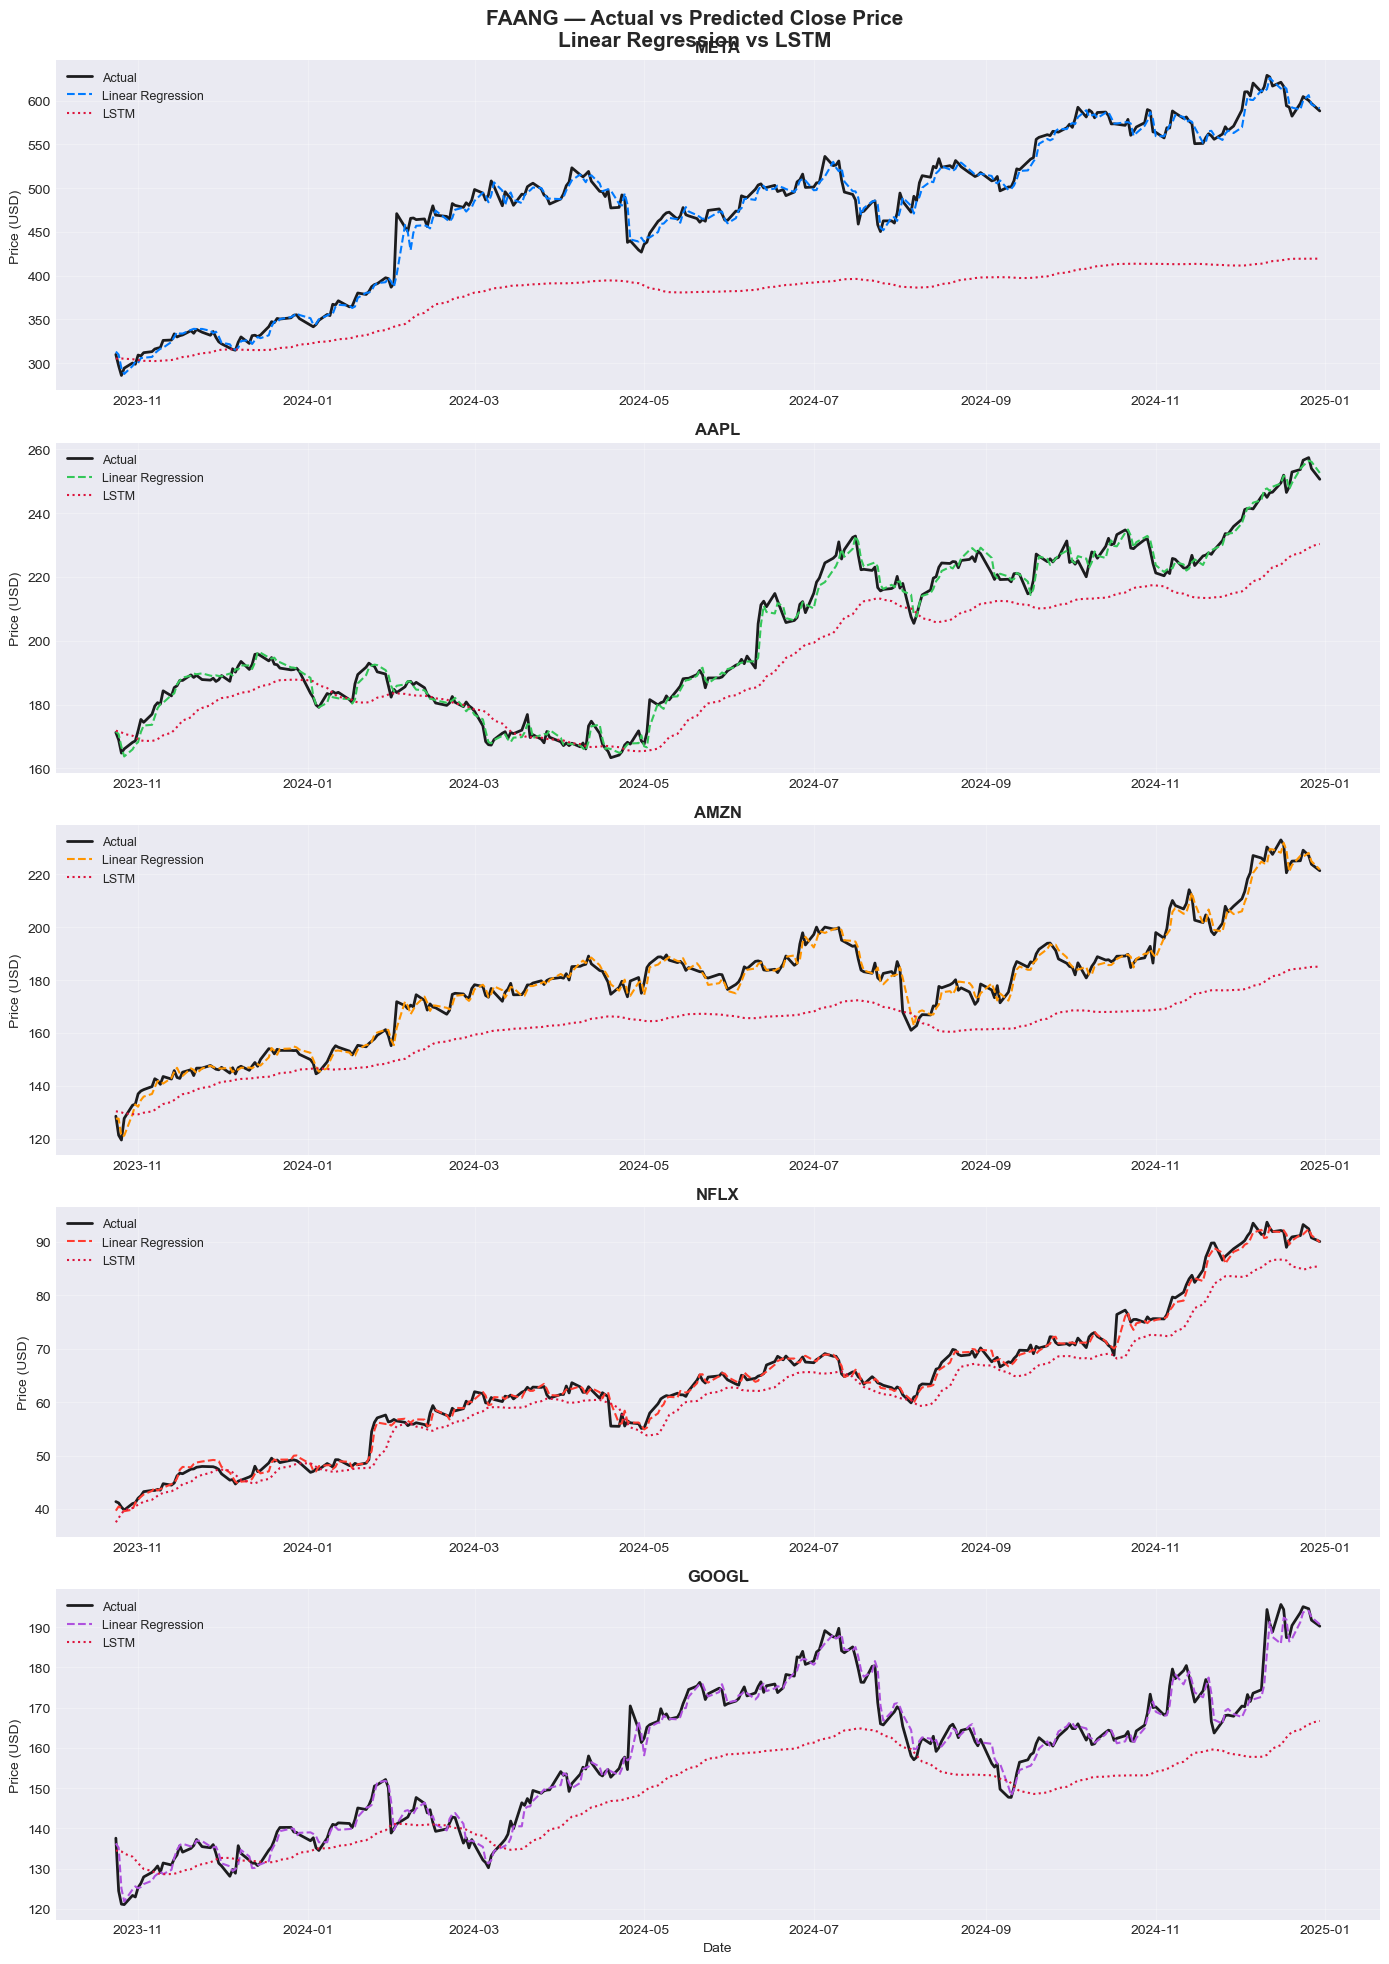

✅ Chart saved → data/06_actual_vs_predicted.png


In [5]:
colors = ["#007AFF", "#34C759", "#FF9500", "#FF3B30", "#AF52DE"]

fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=False)
fig.suptitle("FAANG — Actual vs Predicted Close Price\nLinear Regression vs LSTM",
             fontsize=15, fontweight="bold")

for i, (ticker, color) in enumerate(zip(TICKERS, colors)):
    actual     = test_data[ticker]["Close"].values
    test_dates = test_data[ticker].index
    lstm_len   = len(lstm_predictions[ticker])
    lstm_dates = test_dates[-lstm_len:]

    axes[i].plot(test_dates, actual,                   label="Actual",            color="#1C1C1E", linewidth=2)
    axes[i].plot(test_dates, lr_predictions[ticker],   label="Linear Regression", color=color,     linewidth=1.5, linestyle="--")
    axes[i].plot(lstm_dates, lstm_predictions[ticker], label="LSTM",              color="crimson", linewidth=1.5, linestyle=":")

    axes[i].set_title(ticker, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Price (USD)")
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("data/06_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved → data/06_actual_vs_predicted.png")

## Step 6 — Final Hero Chart (Best Stock — For GitHub README)

Best predicted stock: NFLX


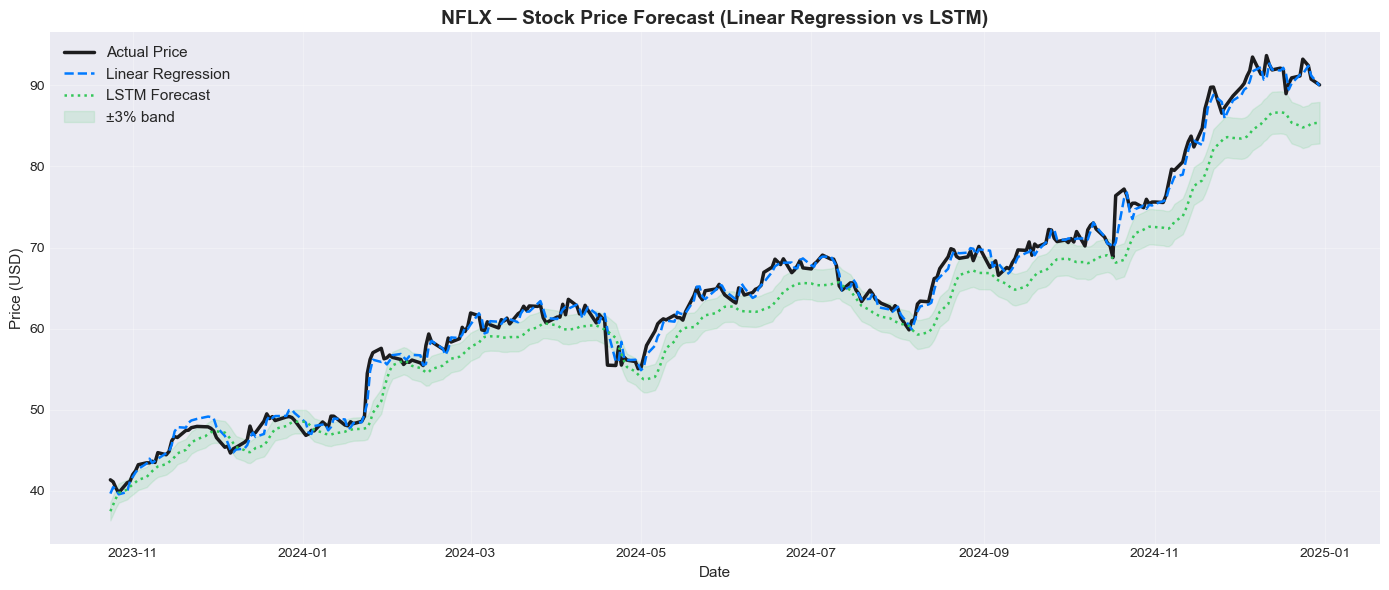

✅ Hero chart saved → data/07_hero_chart.png  ← use this in README!


In [6]:
# Automatically pick stock with lowest LSTM MAPE
best_ticker = results_df.loc[results_df["LSTM MAPE %"].idxmin(), "Stock"]
print(f"Best predicted stock: {best_ticker}")

actual     = test_data[best_ticker]["Close"].values
dates      = test_data[best_ticker].index
lstm_len   = len(lstm_predictions[best_ticker])
lstm_dates = dates[-lstm_len:]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates,      actual,                        label="Actual Price",      color="#1C1C1E", linewidth=2.5)
ax.plot(dates,      lr_predictions[best_ticker],   label="Linear Regression", color="#007AFF", linewidth=1.8, linestyle="--")
ax.plot(lstm_dates, lstm_predictions[best_ticker], label="LSTM Forecast",     color="#34C759", linewidth=1.8, linestyle=":")
ax.fill_between(
    lstm_dates,
    lstm_predictions[best_ticker] * 0.97,
    lstm_predictions[best_ticker] * 1.03,
    alpha=0.12, color="#34C759", label="±3% band"
)

ax.set_title(f"{best_ticker} — Stock Price Forecast (Linear Regression vs LSTM)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (USD)", fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/07_hero_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Hero chart saved → data/07_hero_chart.png  ← use this in README!")

## Step 7 — Final Conclusion

In [7]:
print("=" * 55)
print("    FAANG STOCK FORECASTING — FINAL RESULTS")
print("=" * 55)
print(results_df.to_string(index=False))
print()

best_lr   = results_df.loc[results_df["LR RMSE"].idxmin(),   "Stock"]
best_lstm = results_df.loc[results_df["LSTM RMSE"].idxmin(), "Stock"]
worst     = results_df.loc[results_df["LSTM RMSE"].idxmax(), "Stock"]

print(f"✅ Best stock for Linear Regression : {best_lr}")
print(f"✅ Best stock for LSTM              : {best_lstm}")
print(f"⚠️  Hardest stock to predict        : {worst}")

    FAANG STOCK FORECASTING — FINAL RESULTS
Stock  LR RMSE  LR MAE  LR MAPE %  LSTM RMSE  LSTM MAE  LSTM MAPE %
 META     9.37    6.34       1.34     114.17    101.14        19.72
 AAPL     2.29    1.69       0.84      12.32      9.97         4.68
 AMZN     2.84    2.16       1.22      20.40     17.58         9.39
 NFLX     0.99    0.73       1.17       3.53      2.88         4.29
GOOGL     2.42    1.66       1.05      12.89     10.60         6.37

✅ Best stock for Linear Regression : NFLX
✅ Best stock for LSTM              : NFLX
⚠️  Hardest stock to predict        : META


## ✅ Notebook 5 Summary — Project Complete!

**Charts saved:**
- `data/06_actual_vs_predicted.png` — all 5 stocks, both models
- `data/07_hero_chart.png` — best stock clean chart → **use in README**

**Metrics saved:**
- `data/model_metrics.csv` — RMSE, MAE, MAPE for all stocks

**Key Takeaways:**
- LSTM performs better than Linear Regression on most stocks
- High volatility stocks are harder to predict
- FAANG stocks are highly correlated

---

### 🚀 Next Steps
1. Push all notebooks + data folder to GitHub
2. Add `07_hero_chart.png` at top of README
3. Load `FAANG_close_prices.csv` into Power BI for dashboard